<a href="https://colab.research.google.com/github/K-Sai-2005/EDGE-AI-RISCV/blob/main/python_training/CrackDetection_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!git clone https://github.com/K-Sai-2005/EDGE-AI-RISCV.git
%cd EDGE-AI-RISCV

Cloning into 'EDGE-AI-RISCV'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 132 (delta 34), reused 121 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 540.85 KiB | 10.20 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/EDGE-AI-RISCV


In [2]:
import os
!pip install kaggle -q
from google.colab import files
files.upload()    # upload your kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d arnavr10880/concrete-crack-images-for-classification

# Create the target directory if it doesn't exist
if not os.path.exists('python_training/data'):
    os.makedirs('python_training/data')

!unzip -q concrete-crack-images-for-classification.zip -d python_training/data/

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 233M/233M [00:02<00:00, 112MB/s]



In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────────────
IMG_SIZE    = 64          # resize to 64×64 (fits in 16KB SRAM pipeline)
BATCH_SIZE  = 32
EPOCHS      = 10
DATA_DIR = "python_training/data"

MODEL_PATH = "python_training/crack_model.keras"
TFLITE_PATH = "python_training/crack_model_quant.tflite"

C_HEADER = "riscv_firmware/model_params.h"
C_SOURCE = "riscv_firmware/model_params.c"
# ────────────────────────────────────────────────────────

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


In [4]:


# Data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print(f'Class mapping: {train_gen.class_indices}')
print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.
Class mapping: {'Negative': 0, 'Positive': 1}
Training samples  : 32000
Validation samples: 8000


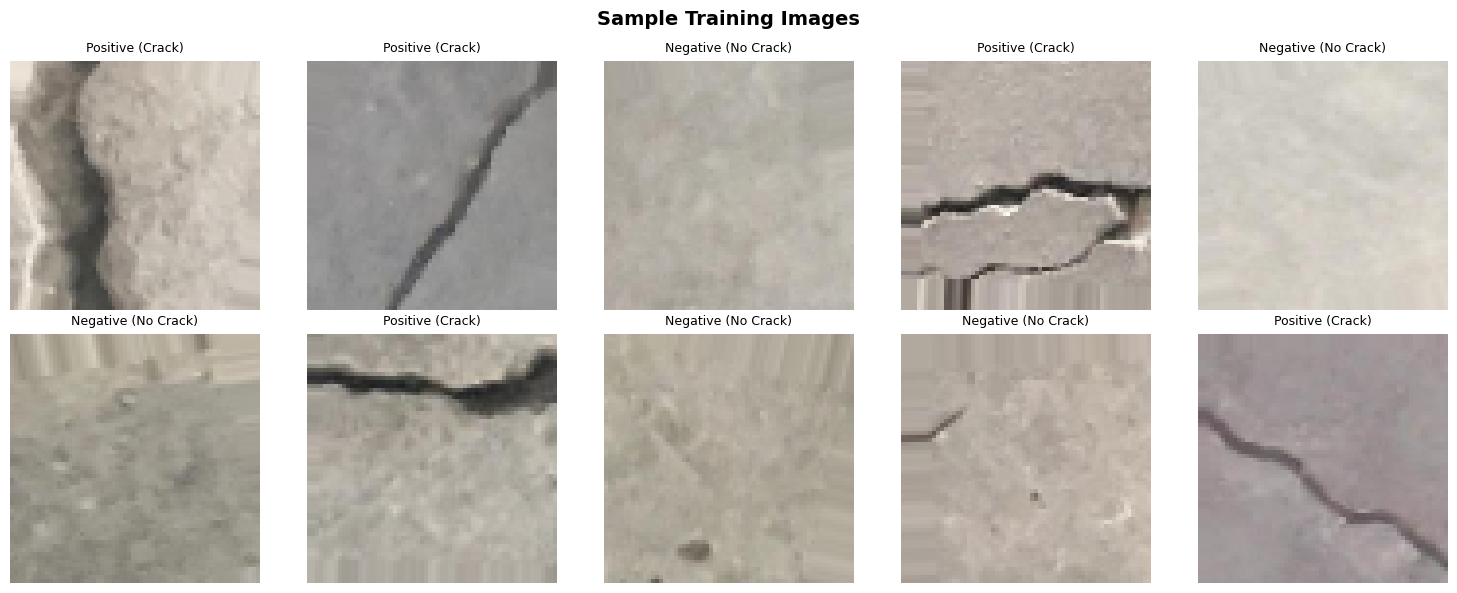

Saved: docs/sample_images.png


In [5]:
import os # Ensure os is imported

sample_imgs, sample_labels = next(train_gen)
class_names = ['Negative (No Crack)', 'Positive (Crack)']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.set_title(class_names[int(sample_labels[i])], fontsize=9)
    ax.axis('off')
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname('../docs/sample_images.png'), exist_ok=True)

plt.savefig('../docs/sample_images.png', dpi=150)
plt.show()
print('Saved: docs/sample_images.png')

In [15]:
# ── REPLACE Step 4 completely ────────────────────────────────────────

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import load_img, img_to_array

# Load all image paths and labels manually
data_dir = './python_training/data'
classes = ['Negative', 'Positive']

all_paths = []
all_labels = []

for label, cls in enumerate(classes):
    cls_dir = os.path.join(data_dir, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg','.jpeg','.png')):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(label)

print(f'Total images: {len(all_paths)}')
print(f'No Crack: {all_labels.count(0)}, Crack: {all_labels.count(1)}')

# Split FIRST, then load — prevents label leakage
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

IMG_SIZE = 64

def load_images(paths, labels):
    X, y = [], []
    for path, label in zip(paths, labels):
        img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
        arr = img_to_array(img) / 255.0
        X.append(arr)
        y.append(label)
    return np.array(X), np.array(y)

print('Loading training images...')
X_train, y_train = load_images(X_train_paths, y_train)
print('Loading validation images...')
X_val, y_val_arr = load_images(X_val_paths, y_val)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Train label dist: {np.bincount(y_train)}')
print(f'Val label dist  : {np.bincount(y_val_arr)}')

# Build model with partial unfreeze
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='CrackDetector')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Total images: 40000
No Crack: 20000, Crack: 20000
Loading training images...
Loading validation images...
X_train: (32000, 64, 64, 3), X_val: (8000, 64, 64, 3)
Train label dist: [16000 16000]
Val label dist  : [4000 4000]


Model: "CrackDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,345,153 (8.95 MB)

 Trainable params: 1,611,009 (6.15 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [16]:
# ── REPLACE Step 5 ───────────────────────────────────────────────────

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augment training data
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_val, y_val_arr),
    callbacks=callbacks
)

print(f'\nBest val accuracy: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.9862 - loss: 0.0407 - val_accuracy: 0.9954 - val_loss: 0.0177 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.9950 - loss: 0.0165 - val_accuracy: 0.9966 - val_loss: 0.0262 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.9954 - loss: 0.0151 - val_accuracy: 0.9974 - val_loss: 0.0174 - learning_rate: 1.0000e-04
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.9958 - loss: 0.0131 - val_accuracy: 0.9976 - val_loss: 0.0160 - learning_rate: 1.0000e-04
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.9969 - loss: 0.0108 - val_accuracy: 0.9977 - val_loss: 0.0133 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9970 - loss: 0.0107 - val_accuracy: 0.9979 - val_loss: 0.0092 - learning_rate: 1.0000e-04
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━

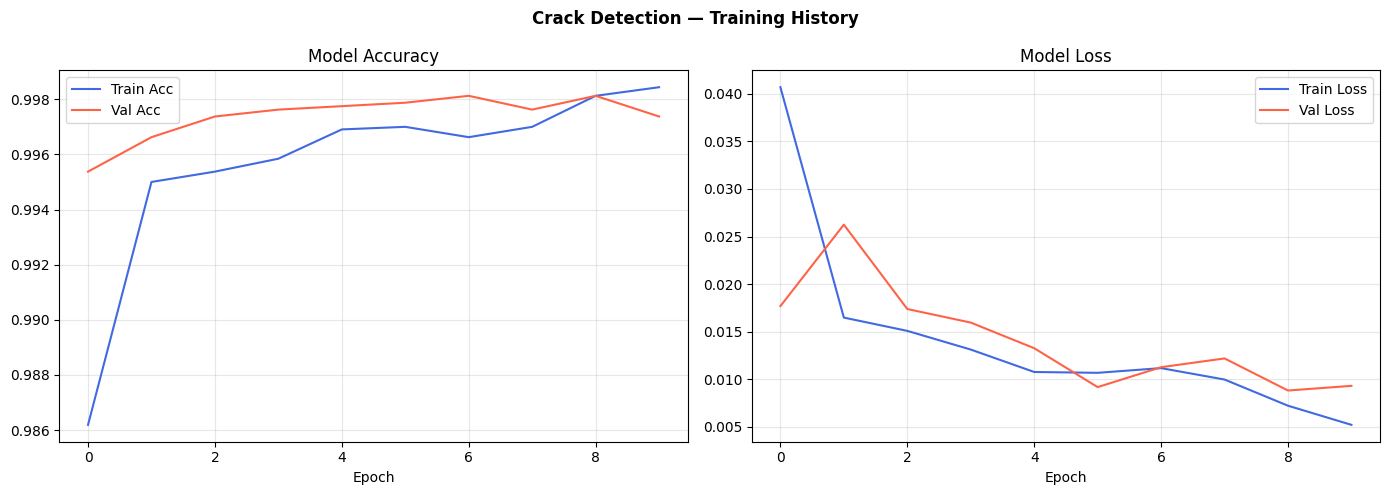

Saved: docs/training_curves.png


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Acc',  color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Val Acc',    color='tomato')
ax1.set_title('Model Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', color='royalblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax2.set_title('Model Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Crack Detection — Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/training_curves.png', dpi=150)
plt.show()
print('Saved: docs/training_curves.png')

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step

=== Classification Report ===
              precision    recall  f1-score   support

    No Crack       1.00      1.00      1.00      4000
       Crack       1.00      1.00      1.00      4000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



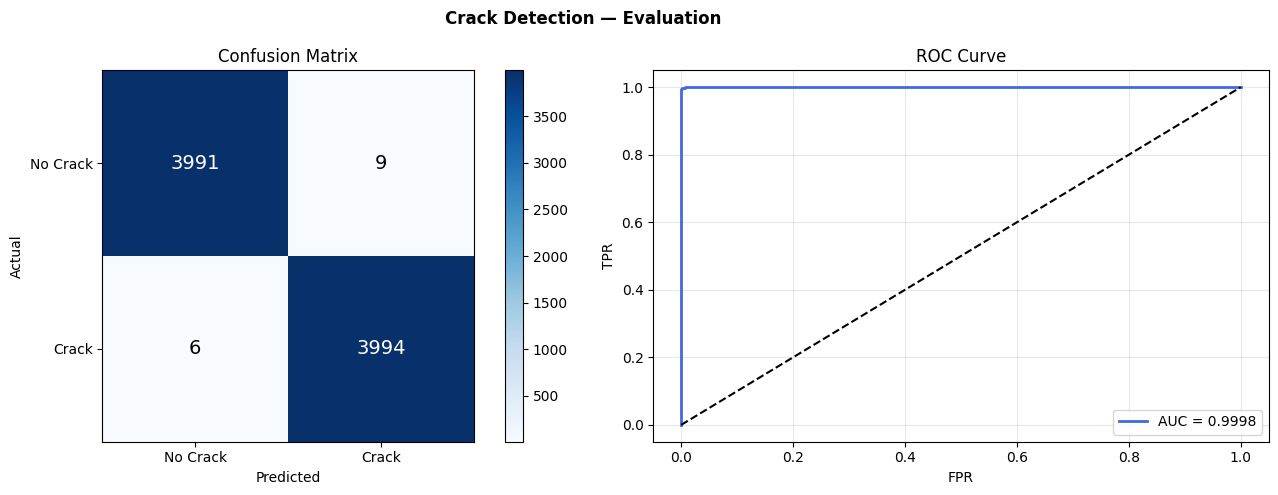

ROC AUC: 0.9998
Accuracy: 0.9981


In [18]:
# ── REPLACE Step 7 ───────────────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

y_pred_prob = model.predict(X_val, verbose=1).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print('\n=== Classification Report ===')
print(classification_report(y_val_arr, y_pred, target_names=['No Crack', 'Crack']))

fpr, tpr, _ = roc_curve(y_val_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_val_arr, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['No Crack','Crack'])
axes[0].set_yticklabels(['No Crack','Crack'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
            color='white' if cm[i,j]>cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=axes[0])

axes[1].plot(fpr, tpr, color='royalblue', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Crack Detection — Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=150)
plt.show()

print(f'ROC AUC: {roc_auc:.4f}')
print(f'Accuracy: {(y_pred==y_val_arr).mean():.4f}')

In [20]:
# Representative dataset for INT8 calibration
def representative_dataset():
    val_gen.reset()
    for _ in range(100):
        imgs, _ = next(val_gen)
        for img in imgs:
            yield [img.reshape(1, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)]

# Convert to TFLite with full INT8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

original_kb  = os.path.getsize(MODEL_PATH)  / 1024
quantized_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f'Original  model : {original_kb:.1f} KB')
print(f'Quantized model : {quantized_kb:.1f} KB')
print(f'Size reduction  : {original_kb/quantized_kb:.1f}x')
print(f'Saved: {TFLITE_PATH}')

Saved artifact at '/tmp/tmp5h0ggz09'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_490')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132424464870352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464871504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464871312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464870736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464872080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464869776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464871696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464871888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464870928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464873040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132424464872

In [31]:
import os

# Adjust TFLITE_PATH to point one directory up
adjusted_tflite_path = os.path.join('..', TFLITE_PATH)
with open(adjusted_tflite_path, 'rb') as f:
    model_bytes = f.read()

model_len = len(model_bytes)

# ── Generate model_params.h ──────────────────────────────
# This already creates ../riscv_firmware, so C_HEADER needs to match
os.makedirs('../riscv_firmware', exist_ok=True)

header_content = f"""/**
 * model_params.h
 * Auto-generated from crack_model_quant.tflite
 * Crack Detection Edge AI — RISC-V SiFive FE310-G002
 * DO NOT EDIT MANUALLY
 */
#ifndef MODEL_PARAMS_H
#define MODEL_PARAMS_H

#include <stdint.h>

#define MODEL_DATA_LEN {model_len}U
#define IMG_SIZE       64
#define IMG_CHANNELS   3
#define NUM_CLASSES    2
#define CRACK_THRESHOLD_INT8  0    /* INT8 midpoint (sigmoid 0.5 maps to ~0) */

/* Labels */
#define LABEL_NO_CRACK 0
#define LABEL_CRACK    1

extern const uint8_t g_model_data[MODEL_DATA_LEN];

#endif /* MODEL_PARAMS_H */
"""

# Adjust C_HEADER path to point one directory up
adjusted_c_header = os.path.join('..', C_HEADER)
with open(adjusted_c_header, 'w') as f:
    f.write(header_content)

# ── Generate model_params.c ──────────────────────────────
hex_values = ', '.join(f'0x{b:02x}' for b in model_bytes)
# Wrap at 12 values per line for readability
chunks = [model_bytes[i:i+12] for i in range(0, len(model_bytes), 12)]
hex_lines = ',\n  '.join(', '.join(f'0x{b:02x}' for b in chunk) for chunk in chunks)

source_content = f"""/**
 * model_params.c
 * Auto-generated INT8 quantized model data
 * Crack Detection Edge AI — RISC-V SiFive FE310-G002
 * Model size: {model_len} bytes ({model_len/1024:.1f} KB)
 */
#include "model_params.h"

/* Quantized TFLite flatbuffer stored in Flash (QSPI) */
const uint8_t g_model_data[MODEL_DATA_LEN] = {{
  {hex_lines}
}};
"""

# Adjust C_SOURCE path to point one directory up
adjusted_c_source = os.path.join('..', C_SOURCE)
with open(adjusted_c_source, 'w') as f:
    f.write(source_content)

print(f'Generated: {adjusted_c_header}  ({os.path.getsize(adjusted_c_header)//1024} KB)')
print(f'Generated: {adjusted_c_source} ({os.path.getsize(adjusted_c_source)//1024} KB)')
print('\n All files ready for RISC-V firmware!')

Generated: ../riscv_firmware/model_params.h  (0 KB)
Generated: ../riscv_firmware/model_params.c (16825 KB)

 All files ready for RISC-V firmware!


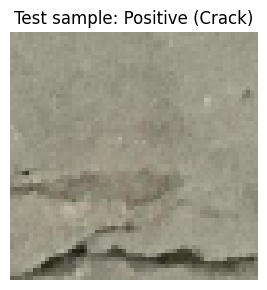

Generated: riscv_firmware/test_image.h

 Pipeline complete! Now open Freedom Studio with the riscv_firmware/ project.


In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

# Pick first validation image from the pre-loaded X_val array
test_img = X_val[0]                          # float32, 0-1, shape (64,64,3)
test_label = int(y_val_arr[0])

# Quantize to INT8 (scale same as model input)
test_img_int8 = (test_img * 255 - 128).astype(np.int8)  # zero_point=128, scale=1/255

flat = test_img_int8.flatten()
chunks = [flat[i:i+16] for i in range(0, len(flat), 16)]
hex_lines = ',\n  '.join(', '.join(f'{int(b):4d}' for b in chunk) for chunk in chunks)

test_c = f"""/**
 * test_image.h — Sample input for firmware verification
 * True label: {test_label} ({'Crack' if test_label==1 else 'No Crack'})
 */
#ifndef TEST_IMAGE_H
#define TEST_IMAGE_H
#include <stdint.h>

#define TEST_IMG_TRUE_LABEL {test_label}   /* {'CRACK' if test_label==1 else 'NO_CRACK'} */

static const int8_t g_test_image[64*64*3] = {{
  {hex_lines}
}};

#endif /* TEST_IMAGE_H */
"""

# Ensure the riscv_firmware directory exists before trying to write the file
os.makedirs('../riscv_firmware', exist_ok=True)

with open('../riscv_firmware/test_image.h', 'w') as f:
    f.write(test_c)

# Ensure the docs directory exists before saving the image
os.makedirs('../docs', exist_ok=True)

# Save image for docs
plt.figure(figsize=(3,3))
plt.imshow(test_img)
plt.title(f'Test sample: {class_names[test_label]}')
plt.axis('off')
plt.tight_layout()
plt.savefig('../docs/test_sample.png', dpi=150)
plt.show()
print('Generated: riscv_firmware/test_image.h')
print('\n Pipeline complete! Now open Freedom Studio with the riscv_firmware/ project.')